In [1]:
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [57]:
#original - no NO-GO zone plotting

import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure ############
cortical_space = space.RandomStructure(boundary=space.Sphere(2000))
STN_space = space.RandomStructure(boundary=space.Sphere(2000))

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(100, cortical_type, structure=cortical_space, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(100, STN_type, structure=STN_space, initial_values={'v': v_init}, label="STN neurons")


##### check no neurons in the no go area####
# stn neurons
for STN_cell in STN_pop:
    while (
        (np.abs(STN_cell.position[0]) > 4000)
        or ((np.abs(STN_cell.position[1]) > 4000))
        or (np.abs(STN_cell.position[2]) > 12000)
    ) or (
        (-150 < STN_cell.position[0] < 150)
            and (-317.5 < STN_cell.position[2] < 317.5)
        ):
            STN_cell.position = STN_space.generate_positions(1).flatten()

for Cortical_cell in cortical_pop:
    while (
        (np.abs(Cortical_cell.position[0]) > 8000)
        or ((np.abs(Cortical_cell.position[1]) > 8000))
         or ((np.abs(Cortical_cell.position[2]) > 8000))
        ) or (
            (-150 < Cortical_cell.position[0] < 150)
            and (-67.5 < Cortical_cell.position[2] < 567.5) #z limit -317.5 < z < 317.5 but offset by +250
        ):
        Cortical_cell.position = cortical_space.generate_positions(1).flatten()

############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)

############ Get and plot data ############
#data = STN_pop.get_data().segments[0]
#vm = data.filter(name="v")[0]

#plt.plot(vm.times, vm)
#plt.xlabel("Time (ms)")
#plt.ylabel("Membrane potential (mV)")
#plt.title("PyNN simulation (HH neuron)")
#plt.show()

####### Clean up ###########
sim.end()

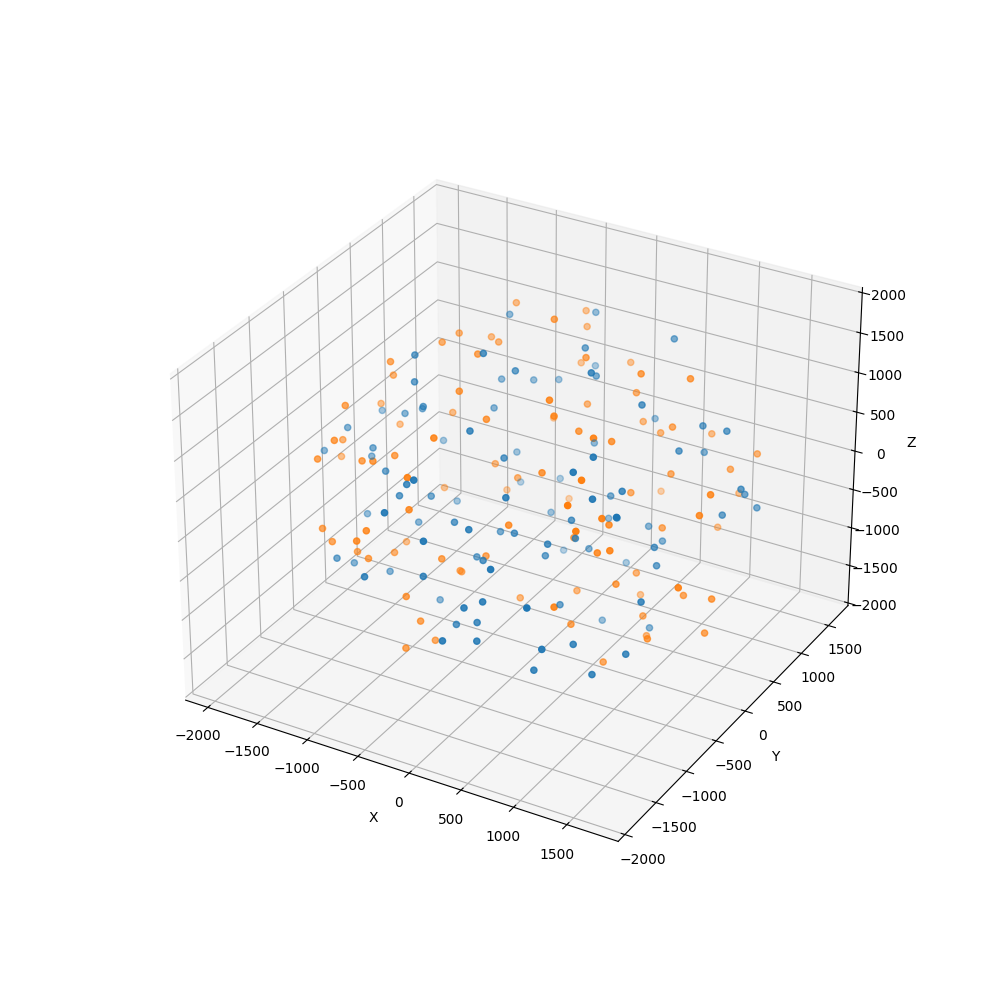

In [58]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn)

plt.show()

In [10]:
class Sphere():
    def __init__(self, radius):
        self.radius = radius
                
    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n
        
        x_points = [] 
        y_points = [] 
        z_points = [] 
        
        theta = np.random.uniform(0, 2 * np.pi, num_points) 
        phi = np.random.uniform(0, np.pi, num_points) 
        x_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))  
        y_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
            
        x_points = x_radius * np.sin(phi) * np.cos(theta)
        y_points = y_radius * np.sin(phi) * np.sin(theta) 
        z_points = z_radius * np.cos(phi)

                   
        for idy, j in enumerate(y_points):
            invalid_y = (-1500 < j) and (j < 2000)
            while invalid_y:
                theta = np.random.uniform(0, 2 * np.pi) 
                phi = np.random.uniform(0, np.pi) 
                y_radius = 2000*np.cbrt(np.random.uniform(0, 1))
                j = y_radius * np.sin(phi) * np.sin(theta) 
                invalid_y = (-1500 < j) and (j < 2000)
            y_points[idy] = j


        for idx, i in enumerate(x_points):
            invalid_x = (-500 < i) and (i < 500)
            while invalid_x:
                theta = np.random.uniform(0, 2 * np.pi) 
                phi = np.random.uniform(0, np.pi) 
                x_radius = 2000*np.cbrt(np.random.uniform(0, 1))
                i = x_radius * np.sin(phi) * np.cos(theta) 
                invalid_x = (-500 < i) and (i < 500)
            x_points[idx] = i

        return x_points, y_points, z_points

In [11]:
ellipse = Sphere(2000)
STN_space = ellipse.generate_positions(100)


In [12]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 500
rotation_angle = 0.610865

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Sphere(2000)
cortical_space = ellipse.generate_positions(n)
STN_space = ellipse.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[0], cortical_space[1], cortical_space[2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[0], STN_space[1], np.ones(n)*500


############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)
'''
############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()
'''
####### Clean up ###########
sim.end()

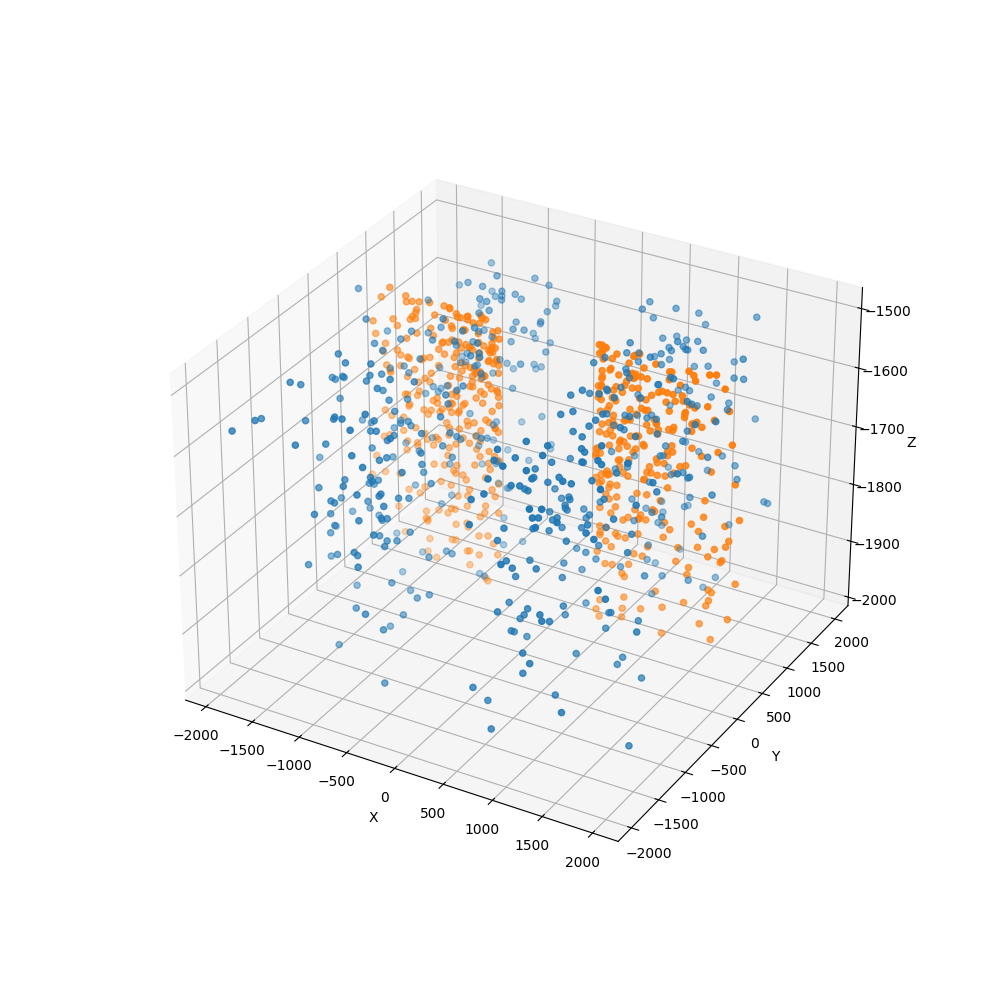

In [13]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn)

plt.show()

In [29]:
class Sphere2():
    def __init__(self, radius):
        self.radius = radius
                
    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n
        
        x_points = [] 
        y_points = [] 
        z_points = [] 
        
        theta = np.random.uniform(0, 2 * np.pi, num_points) 
        phi = np.random.uniform(0, np.pi, num_points) 
        x_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))  
        y_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
            
        x_points = x_radius * np.sin(phi) * np.cos(theta)
        y_points = y_radius * np.sin(phi) * np.sin(theta) 
        z_points = z_radius * np.cos(phi)

        invalid_x = (x_points > -500) & (x_points < 500)
        invalid_y = (y_points > -1500) & (y_points < 2000)
        
        invalid = invalid_x & invalid_y

        while np.any(invalid):
            n = invalid.sum()

            # Sample spherical distribution
            theta = np.random.uniform(0, 2*np.pi, n)
            phi   = np.random.uniform(0, np.pi, n)
            r     = 2000 * np.cbrt(np.random.uniform(0, 1, n))

            # Compute new x and y for all invalid points at once
            new_x = r * np.sin(phi) * np.cos(theta)
            new_y = r * np.sin(phi) * np.sin(theta)

            # Assign
            x_points[invalid] = new_x
            y_points[invalid] = new_y

            # Recompute masks
            invalid_x = (x_points > -500) & (x_points < 500)
            invalid_y = (y_points > -1500) & (y_points < 2000)
            invalid = invalid_x & invalid_y

        points = np.column_stack((x_points, y_points, z_points))

            
        return points

In [30]:
ellipse = Sphere2(2000)
STN_space = ellipse.generate_positions(100)
print(STN_space)


[[ -812.46533075   527.75670987  1107.84385253]
 [  557.77838446    -2.73256833  1096.95820433]
 [ -694.71482378   261.45949757 -1559.56942891]
 [-1056.01757801  1445.92854518  -163.51166176]
 [-1287.54333603  1307.37550309   463.47118936]
 [ -712.02747194  -100.77343749 -1484.19780023]
 [  672.33365218 -1313.56515394  -733.7205532 ]
 [ 1221.67015083   956.35888811  -577.00440145]
 [  539.14211009   952.30353856  -218.831394  ]
 [-1320.29035738  -728.58426997  -582.31472814]
 [ 1444.23929131  1062.2105278    -11.42994934]
 [-1349.04893442  -417.5993102   -451.96711953]
 [ 1055.2055816   1558.96379588  1672.82404798]
 [ 1223.02238013   646.18167582 -1864.55762499]
 [-1215.20537806   127.38092476  -341.99735111]
 [ -752.52644477   288.49126848  1096.37495341]
 [  866.22594057   376.23622584 -1866.18751348]
 [ 1154.01432698  -641.98615559   396.71805484]
 [-1007.61739093  -312.76437156  -815.78113576]
 [ 1379.07574752 -1066.30489807 -1358.29870748]
 [  771.18435764  -297.44234781  1323.60

In [31]:
STN_space[:,0]

array([ -812.46533075,   557.77838446,  -694.71482378, -1056.01757801,
       -1287.54333603,  -712.02747194,   672.33365218,  1221.67015083,
         539.14211009, -1320.29035738,  1444.23929131, -1349.04893442,
        1055.2055816 ,  1223.02238013, -1215.20537806,  -752.52644477,
         866.22594057,  1154.01432698, -1007.61739093,  1379.07574752,
         771.18435764, -1736.52151229,   525.07884103,  -771.20318361,
       -1443.93087289,   646.32918656,  1304.92609193, -1180.01046453,
         998.91437248,  -675.73832454,   674.84929797,  -595.45946919,
       -1069.10065215,   684.63512212, -1428.14805439,  -901.54404154,
         787.14801999, -1141.61563509,  -925.97854748,  -685.21917137,
        -872.30687717, -1434.70195581, -1372.93109442, -1096.65156792,
         958.50307532, -1474.73397893,  -591.35022883,  1141.39111099,
        -873.64823867, -1022.98767125, -1023.95097557,  -891.45199668,
        -801.72036723,   843.00423736, -1487.88183087,  1372.66438356,
      

In [33]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 500
rotation_angle = 0.610865

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Sphere2(2000)
cortical_space = ellipse.generate_positions(n)
STN_space = ellipse.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[:,0], cortical_space[:,1], cortical_space[:,2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[:,0], STN_space[:,1], np.ones(n)*500


############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)
'''
############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()
'''
####### Clean up ###########
sim.end()

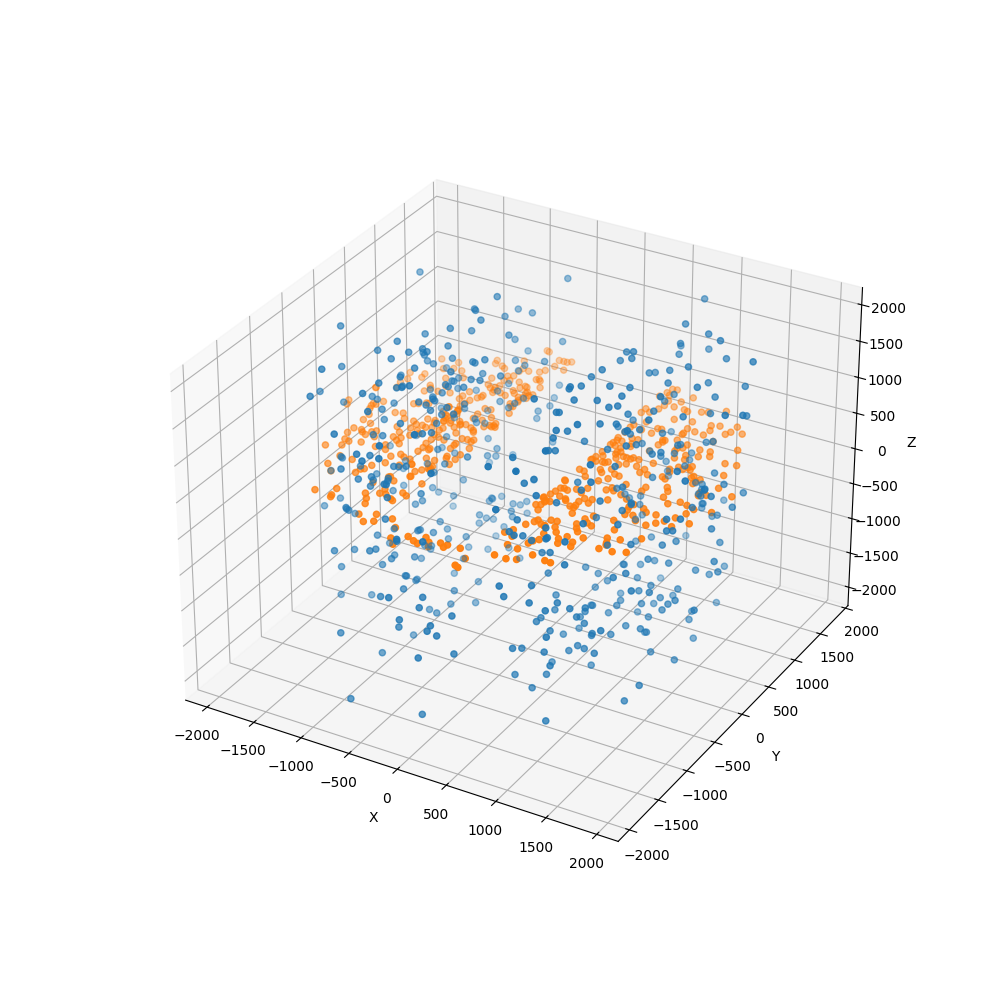

In [34]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, y_points_clean_stn, z_points_clean_stn)

plt.show()